# Segmentacja

In [1]:
import random

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

Wczytujemy przygotowane przez nas klasy z lokalnego pakietu `coronary_analysis`.

In [2]:
from coronary_analysis.models.segmentation import CoronaryUNetCustom
from coronary_analysis.transforms.dca1_transforms import (
    get_train_transforms,
    get_val_transforms,
)
from coronary_analysis.datasets import (
    ArcadeSyntaxBinaryDataset,
    DCA1Dataset,
    get_dca1_pairs,
)
from coronary_analysis.metrics import BCEDiceClDiceCriterion
from coronary_analysis.utils import show_image, plot_lines
from coronary_analysis.metrics import compute_dice_iou_metrics
from coronary_analysis.train import training_loop

Poniżej funkcja ustawia `seed` we wszystkich używanych bibliotekach, aby zapewnić powtarzalność wyników.

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [4]:
set_seed(42)

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [6]:
BATCH_SIZE = 16
IMG_SIZE = 300

#### ARCADE Pretrening

Stworzenie `DataLoaderów` dla zbiorów treningowego i walidacyjnego dla zbioru ARCADE.

In [7]:
ARCADE_DIR = "raw_datasets/arcade/arcade/syntax"

train_arcade = ArcadeSyntaxBinaryDataset(
    root=ARCADE_DIR,
    split="train",
    transform=get_train_transforms(IMG_SIZE),
)
val_arcade = ArcadeSyntaxBinaryDataset(
    root=ARCADE_DIR,
    split="val",
    transform=get_val_transforms(IMG_SIZE),
)

train_loader_arcade = DataLoader(
    train_arcade,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)
val_loader_arcade = DataLoader(
    val_arcade,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

/home/lukasz/Documents/coronary-stenosis-detection/coronary-analysis/src/coronary_analysis/transforms/dca1_transforms.py:11: UserWarning: Argument(s) 'shift_limit, scale_limit, rotate_limit' are not valid for transform Affine
  A.Affine(


loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [8]:
LR = 1e-3
WEIGHT_DECAY = 1e-4

# model = CoronaryUNet(encoder_name="resnet18").to(device)
model = CoronaryUNetCustom(
    encoder_name="resnet18", encoder_weights=None, dropout=0.6
).to(device)
# model = CoronaryDeeplabV3Plus(encoder_name="resnet18").to(device)
# model = CoronaryUNetPP(encoder_name="resnet18").to(device)
# criterion = BCEDiceCriterion(bce_weight=0.5, dice_weight=0.5)
criterion = BCEDiceClDiceCriterion(bce_weight=0.4, dice_weight=0.4, cldice_weight=0.2)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

In [9]:
model.eval()

CoronaryUNetCustom(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affi

Pretrening przy użyciu zbioru ARCADE

In [10]:
history = training_loop(
    model=model,
    train_loader=train_loader_arcade,
    val_loader=val_loader_arcade,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=50,
    scheduler=scheduler,
)

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Train [1/50]:   0%|          | 0/63 [00:00<?, ?batch/s]

Val [1/50]:   0%|          | 0/13 [00:00<?, ?batch/s]

Train [2/50]:   0%|          | 0/63 [00:00<?, ?batch/s]

Val [2/50]:   0%|          | 0/13 [00:00<?, ?batch/s]

...

Val [48/50]:   0%|          | 0/13 [00:00<?, ?batch/s]

Train [49/50]:   0%|          | 0/63 [00:00<?, ?batch/s]

Val [49/50]:   0%|          | 0/13 [00:00<?, ?batch/s]

Train [50/50]:   0%|          | 0/63 [00:00<?, ?batch/s]

Val [50/50]:   0%|          | 0/13 [00:00<?, ?batch/s]

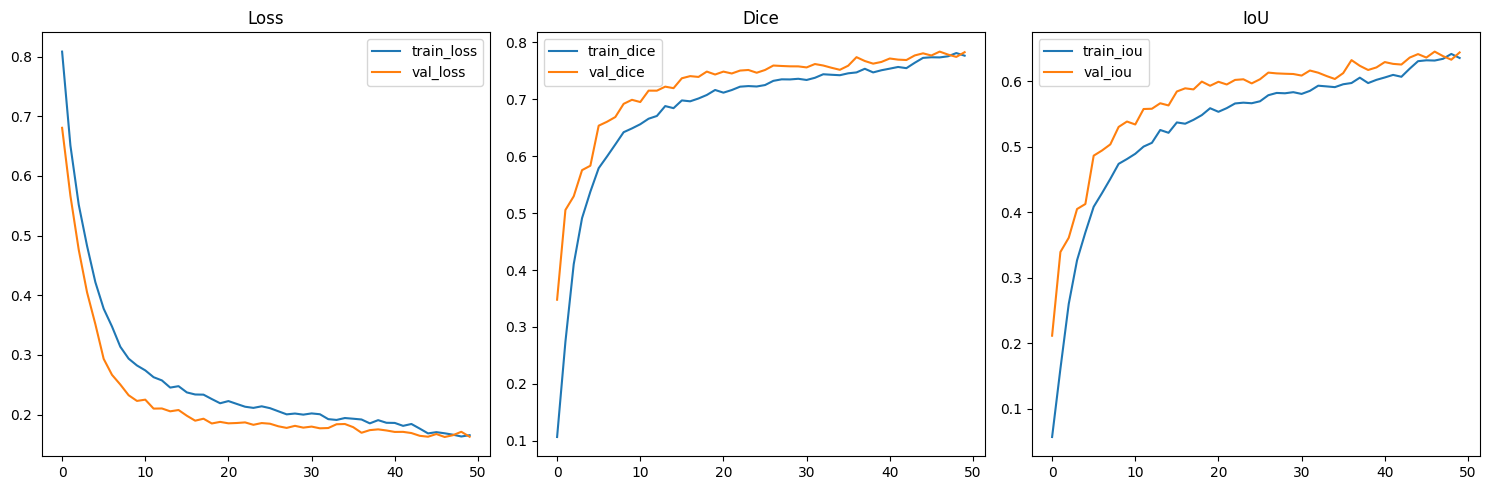

In [11]:
plot_lines(
    history,
    (["train_loss", "val_loss"], "Loss"),
    (["train_dice", "val_dice"], "Dice"),
    (["train_iou", "val_iou"], "IoU"),
)

In [ ]:
IMAGE_DIR = "raw_datasets/DCA1/Database_134_Angiograms"
pairs = get_dca1_pairs(IMAGE_DIR)

train_pairs, val_pairs = train_test_split(pairs, test_size=0.25, random_state=42)

train_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    pairs=train_pairs,
    transform=get_train_transforms(IMG_SIZE),
)
val_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    pairs=val_pairs,
    transform=get_val_transforms(IMG_SIZE),
)

train_loader = DataLoader(
    train_ds,
    batch_size=20,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=20,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

#### DCA1 Fine-tuning

Podział zbioru DCA1 na treningowy i walidacyjny. Używamy funkcji `train_test_split` z biblioteki `sklearn` do losowego podziału danych, zachowując 25% próbek w zbiorze walidacyjnym.

In [12]:
IMAGE_DIR = "raw_datasets/DCA1/Database_134_Angiograms"
pairs = get_dca1_pairs(IMAGE_DIR)

train_pairs, val_pairs = train_test_split(pairs, test_size=0.25, random_state=42)

train_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    pairs=train_pairs,
    transform=get_train_transforms(IMG_SIZE),
)
val_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    pairs=val_pairs,
    transform=get_val_transforms(IMG_SIZE),
)

train_loader = DataLoader(
    train_ds,
    batch_size=20,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=20,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

In [13]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR / 2,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10,
)

Finetuning na zbiorze DCA1

In [14]:
history = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=200,
    scheduler=scheduler,
)

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

Train [1/200]:   0%|          | 0/5 [00:00<?, ?batch/s]

Val [1/200]:   0%|          | 0/2 [00:00<?, ?batch/s]

Train [2/200]:   0%|          | 0/5 [00:00<?, ?batch/s]

Val [2/200]:   0%|          | 0/2 [00:00<?, ?batch/s]

...

Val [198/200]:   0%|          | 0/2 [00:00<?, ?batch/s]

Train [199/200]:   0%|          | 0/5 [00:00<?, ?batch/s]

Val [199/200]:   0%|          | 0/2 [00:00<?, ?batch/s]

Train [200/200]:   0%|          | 0/5 [00:00<?, ?batch/s]

Val [200/200]:   0%|          | 0/2 [00:00<?, ?batch/s]

In [15]:
# TODO: threshold tuning

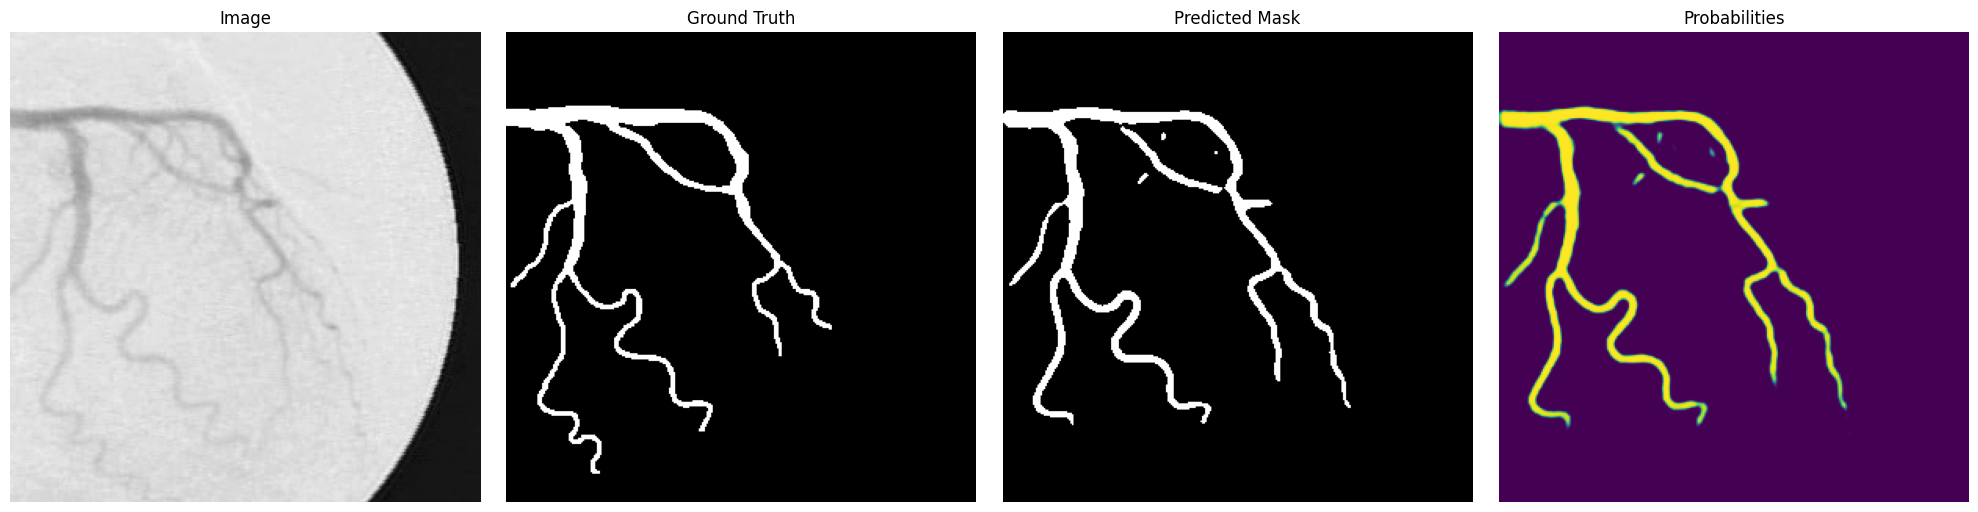

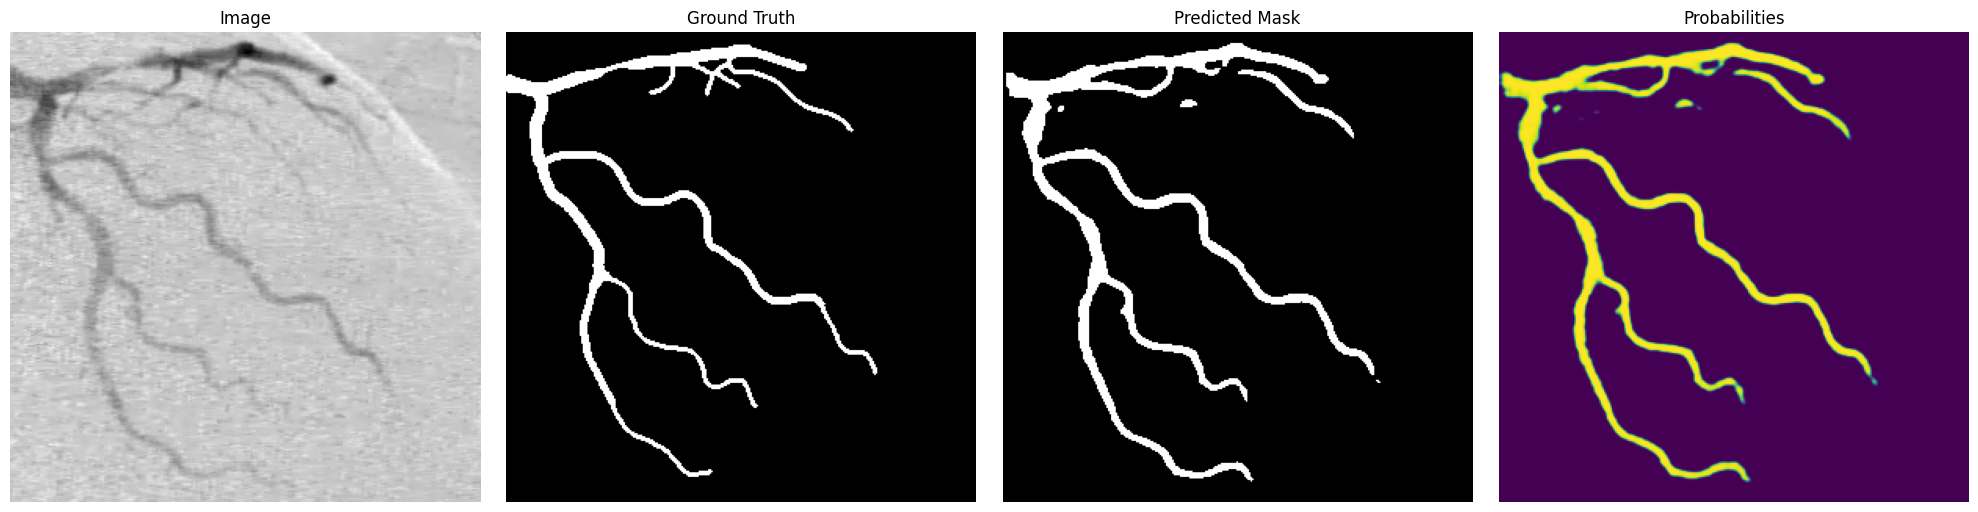

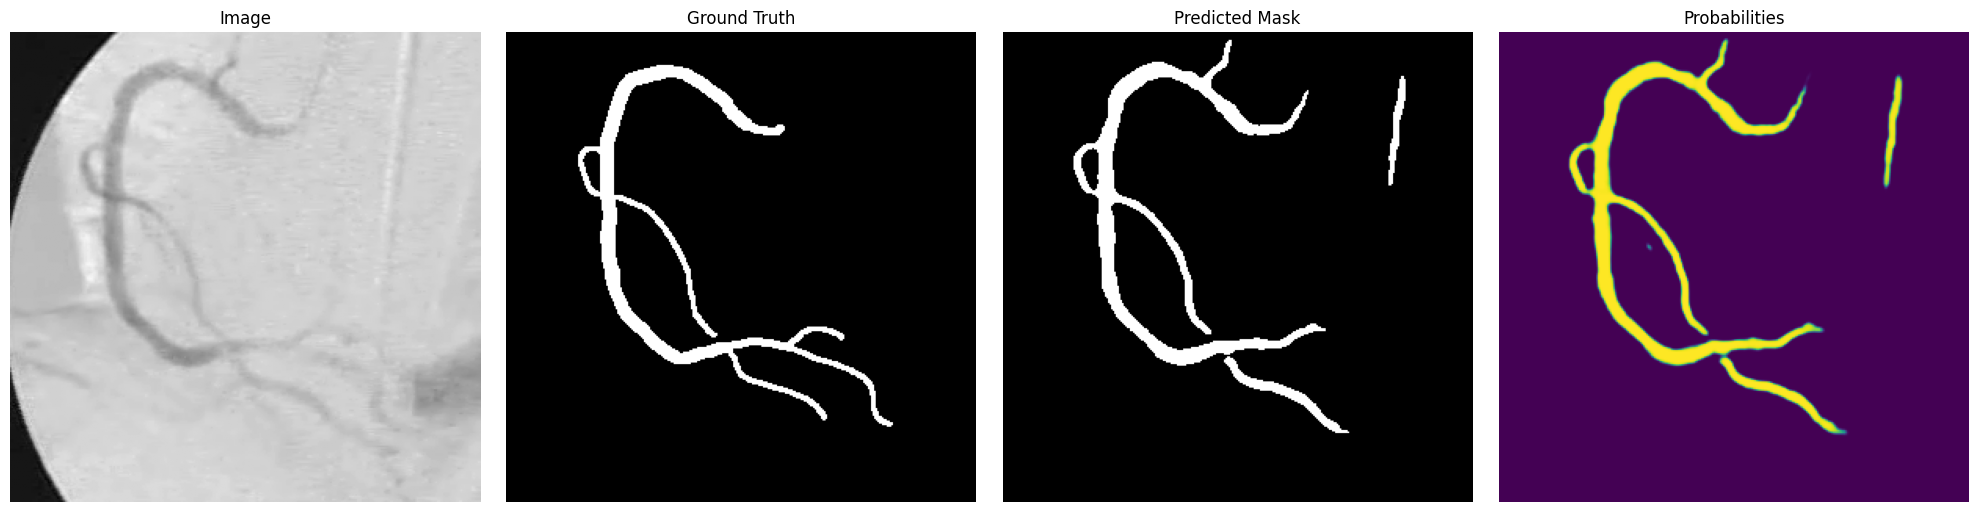

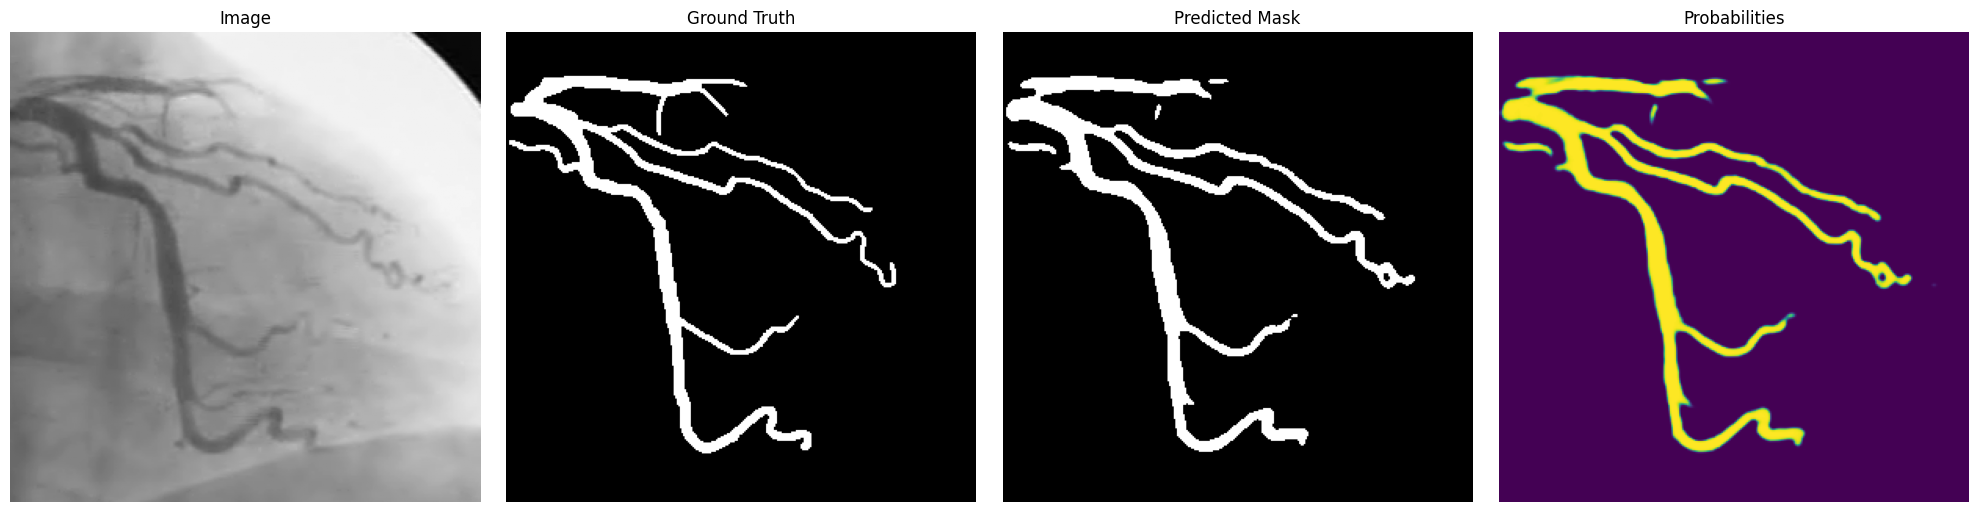

In [16]:
model.eval()

with torch.no_grad():
    val_loader_iter = iter(val_loader)
    for i in range(5 // BATCH_SIZE + 1):
        images, masks = next(val_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        for j in range(min(4, images.size(0))):
            show_image(
                images[j, 0].cpu().numpy(),
                masks[j, 0].cpu().numpy(),
                preds[j, 0].cpu().numpy(),
                probs[j, 0].cpu().numpy(),
                titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
                cmap=["gray", "gray", "gray", None],
            )

Ostateczna walidacja modelu na zbiorze DCA1.

In [17]:
# val metrics

with torch.no_grad():
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    total_samples = 0

    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks).item()
        dice, iou = compute_dice_iou_metrics(logits, masks)

        batch_size = images.size(0)
        val_loss += loss * batch_size
        val_dice += dice * batch_size
        val_iou += iou * batch_size
        total_samples += batch_size

    val_loss /= total_samples
    val_dice /= total_samples
    val_iou /= total_samples

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Dice Coefficient: {val_dice:.4f}")
    print(f"Validation IoU: {val_iou:.4f}")

Validation Loss: 0.1556
Validation Dice Coefficient: 0.7802
Validation IoU: 0.6397


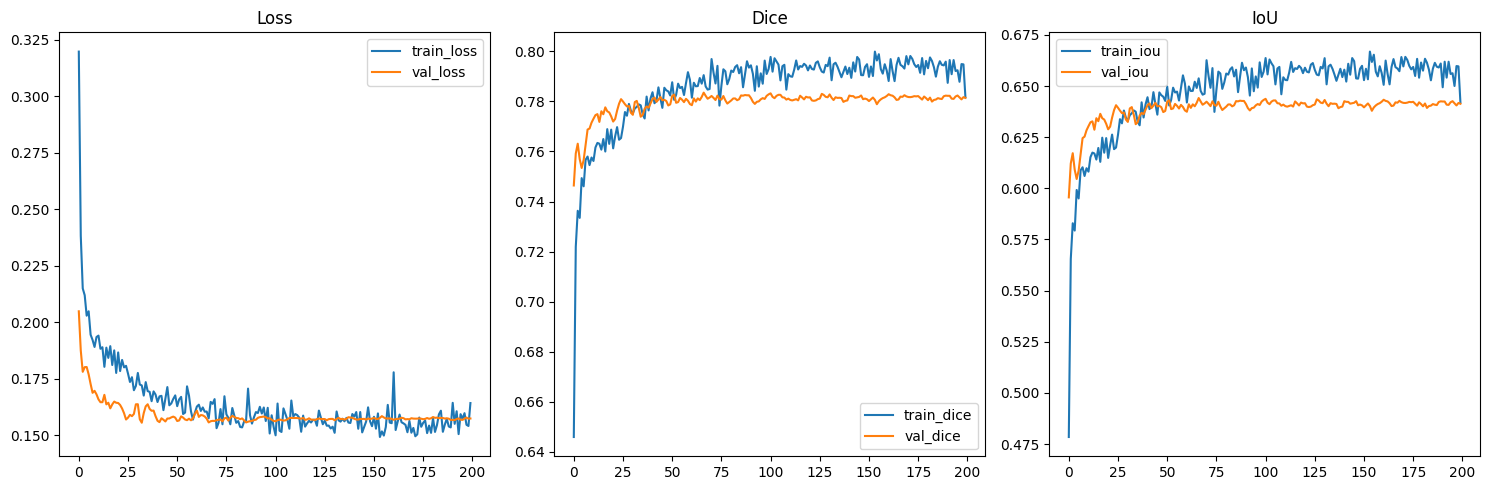

In [18]:
plot_lines(
    history,
    (["train_loss", "val_loss"], "Loss"),
    (["train_dice", "val_dice"], "Dice"),
    (["train_iou", "val_iou"], "IoU"),
)

In [20]:
import os

if not os.path.exists("../models"):
    os.makedirs("../models")

torch.save(model.state_dict(), "../models/best_coronary_unet.pth")

#### Unseen examples from ARCADE

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


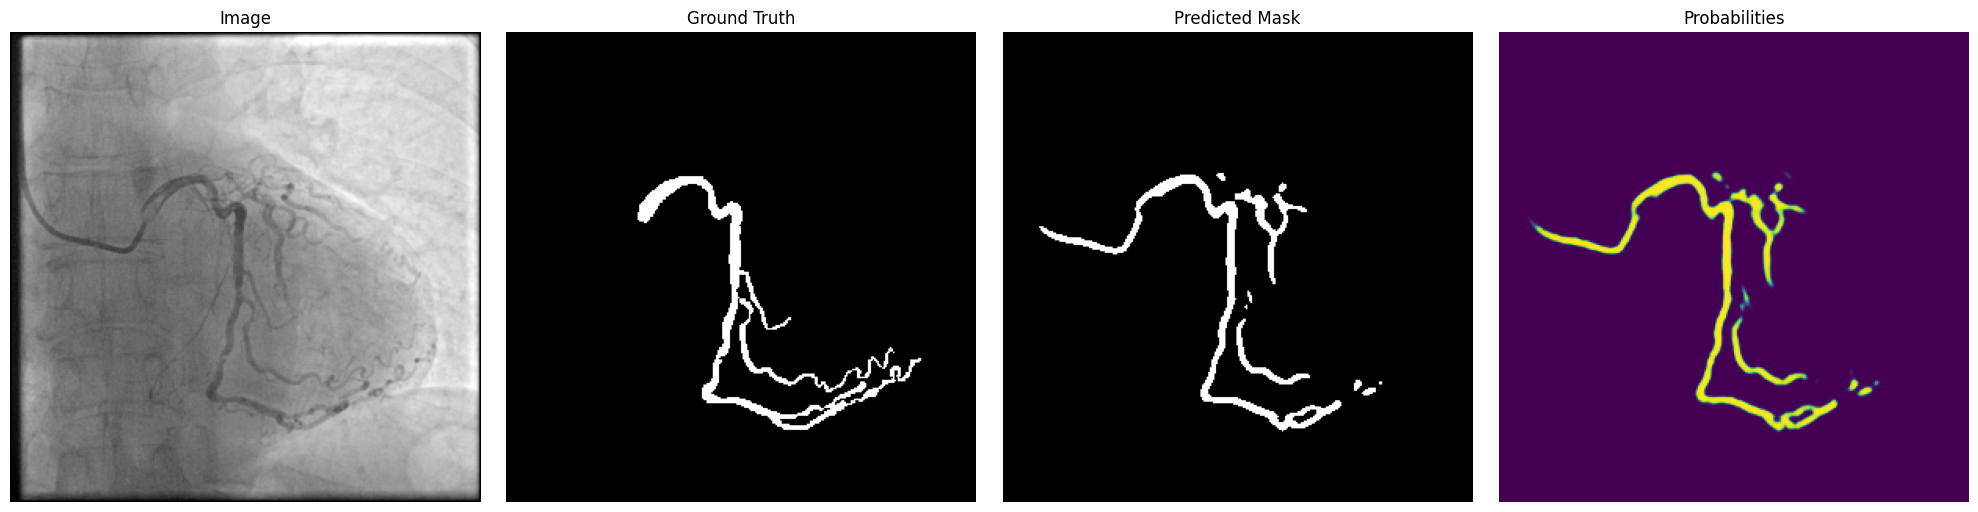

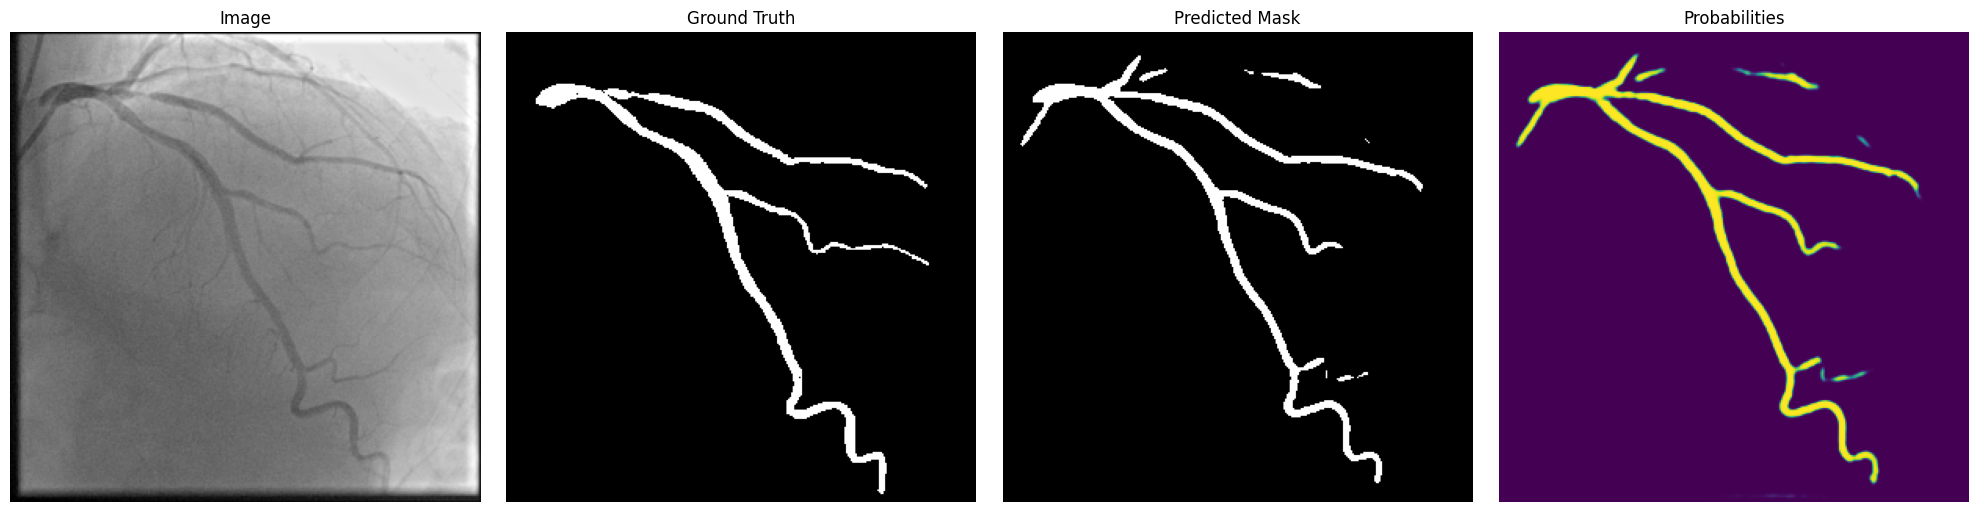

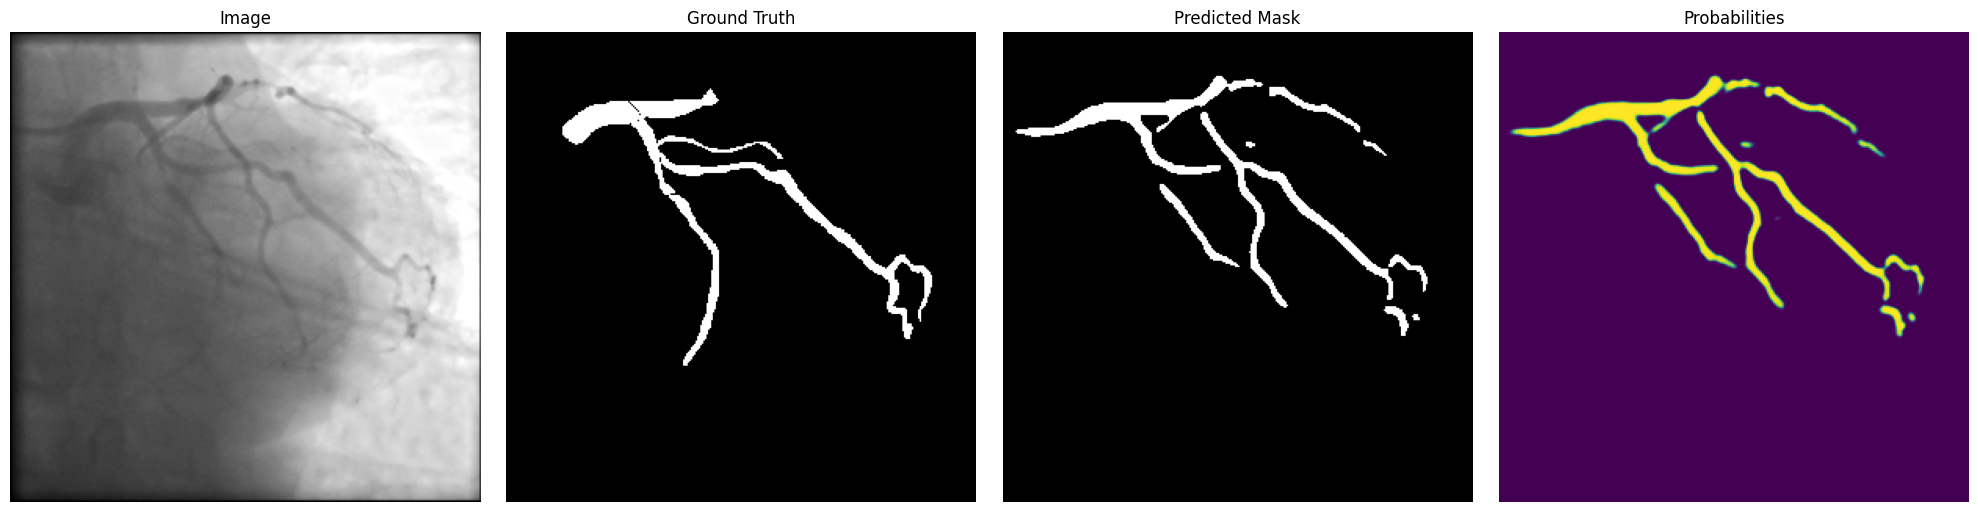

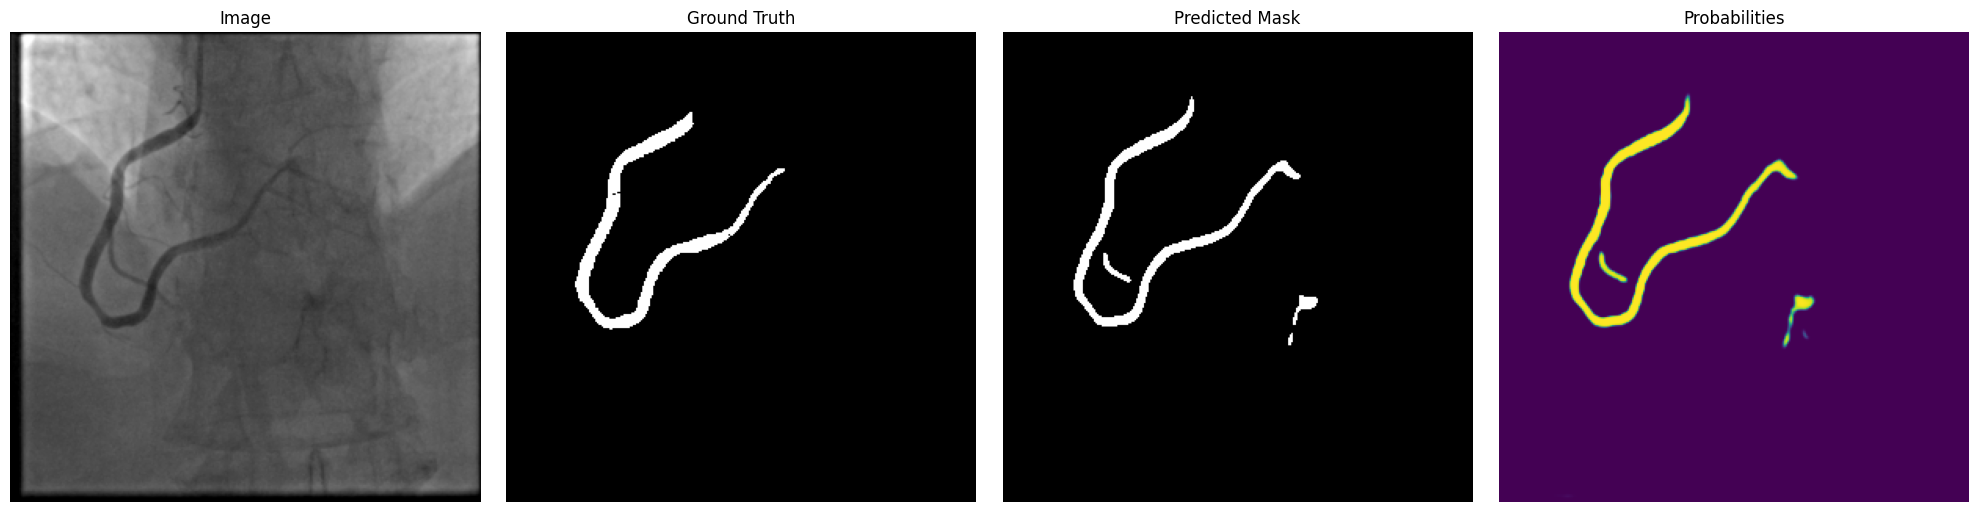

In [21]:
test_arcade = ArcadeSyntaxBinaryDataset(
    root=ARCADE_DIR,
    split="test",
    transform=get_val_transforms(IMG_SIZE),
)

test_loader = DataLoader(
    test_arcade,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

model.eval()

with torch.no_grad():
    test_loader_iter = iter(test_loader)
    for i in range(5 // BATCH_SIZE + 1):
        images, masks = next(test_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        for j in range(min(4, images.size(0))):
            show_image(
                images[j, 0].cpu().numpy(),
                masks[j, 0].cpu().numpy(),
                preds[j, 0].cpu().numpy(),
                probs[j, 0].cpu().numpy(),
                titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
                cmap=["gray", "gray", "gray", None],
            )